# Análisis y Evaluación de Modelos Predictivos

Este documento se enfoca en las métricas y técnicas esenciales para medir el desempeño de un modelo de aprendizaje automático tras su entrenamiento. Continuaremos el análisis empleando el conjunto de datos **NSL-KDD**, ampliamente reconocido para la investigación en ciberseguridad y la construcción de Sistemas de Detección de Intrusiones (IDS).

El propósito de esta base de datos es distinguir entre **conexiones legítimas** e **incursiones maliciosas**, ofreciendo un escenario ideal para problemas de clasificación binaria y multiclase. Aunque las topologías de red han evolucionado, este dataset mantiene su vigencia pedagógica gracias a la calidad de sus datos y a la mitigación de sesgos presentes en versiones más antiguas (como KDD'99).

### Origen de los Datos
Puede acceder al repositorio oficial de los archivos utilizados a través del siguiente enlace de Kaggle: **https://www.kaggle.com/datasets/hassan06/nslkdd**.

## 0. Importación de Módulos y Dependencias

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, f1_score, recall_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

## 1. Definición de Herramientas de Apoyo

In [18]:
# Función para seccionar la base de datos en bloques de entrenamiento, validación y testeo
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return train_set, val_set, test_set

In [19]:
# Ensamblaje de un flujo secuencial (pipeline) para variables cuantitativas
num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('rbst_scaler', RobustScaler())
])


In [20]:
# Transformador diseñado para convertir atributos textuales (categóricos) mediante One-Hot y retornar un DataFrame
class CustomOneHotEncoder(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        self._oh = OneHotEncoder()
        self._columns = None
        
    def fit(self, X, y=None):
        X_cat = X.select_dtypes(include=['object'])
        self._columns = pd.get_dummies(X_cat).columns
        self._oh.fit(X_cat)
        return self
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        X_cat = X_copy.select_dtypes(include=['object'])
        X_num = X_copy.select_dtypes(exclude=['object'])
        X_cat_oh = self._oh.transform(X_cat)
        X_cat_oh = pd.DataFrame(X_cat_oh.toarray(), 
                                columns=self._columns, 
                                index=X_copy.index)
        X_copy.drop(list(X_cat), axis=1, inplace=True)
        return X_copy.join(X_cat_oh)

In [21]:
# Clase integradora que acondiciona los datos combinando múltiples flujos y transformadores
class DataFramePreparer(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        self._full_pipeline = None
        self._columns = None
        
    def fit(self, X, y=None):
        num_attribs = list(X.select_dtypes(exclude=['object']))
        cat_attribs = list(X.select_dtypes(include=['object']))
        self._full_pipeline = ColumnTransformer([
                ("num", num_pipeline, num_attribs),
                ("cat", CustomOneHotEncoder(), cat_attribs)
        ])
        self._full_pipeline.fit(X)
        self._columns = pd.get_dummies(X).columns
        return self
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        X_prep = self._full_pipeline.transform(X_copy)
        return pd.DataFrame(X_prep, 
                            columns=self._columns, 
                            index=X_copy.index)

### 2. Carga Inicial de la Información

In [22]:
df = pd.read_csv("KDDTrain+.csv")
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


### 3. Preparación y Transformación de Datos
Procedemos a aislar la variable objetivo de las características predictoras, recategorizando las etiquetas para trabajar un escenario estrictamente binario (tráfico normal versus anomalía).

In [23]:
train_set, val_set, test_set = train_val_test_split(df, stratify='protocol_type')

X_train = train_set.drop("class", axis=1)
y_train = train_set["class"].copy()

X_val = val_set.drop("class", axis=1)
y_val = val_set["class"].copy()

X_test = test_set.drop("class", axis=1)
y_test = test_set["class"].copy()

In [24]:
# Recategorización a formato binario
y_train = np.where(y_train == "normal", "normal", "anomaly")
y_val = np.where(y_val == "normal", "normal", "anomaly")
y_test = np.where(y_test == "normal", "normal", "anomaly")

In [25]:
# Ejecutamos el transformador integrado sobre los conjuntos
preparer = DataFramePreparer()
X_train_prep = preparer.fit_transform(X_train)
X_val_prep = preparer.transform(X_val)
X_test_prep = preparer.transform(X_test)

/tmp/ipykernel_12916/766570491.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_attribs = list(X.select_dtypes(include=['object']))


/tmp/ipykernel_12916/2759415200.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_cat = X.select_dtypes(include=['object'])
/tmp/ipykernel_12916/2759415200.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details 

### 4. Construcción del Modelo Predictivo

In [26]:
# Empleamos 10 iteraciones para agilizar el proceso; un valor mayor como 1000 refinaría la convergencia
clf = LogisticRegression(solver="newton-cg", max_iter=100)
clf.fit(X_train_prep, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 5. Predicción sobre Nuevos Datos

In [27]:
# Ejecutamos las predicciones utilizando la muestra de validación preprocesada
y_pred = clf.predict(X_val_prep)

## 6. Análisis con Matriz de Confusión
Evaluamos la cantidad de predicciones acertadas y desacertadas divididas en Verdaderos Positivos, Verdaderos Negativos, Falsos Positivos y Falsos Negativos.

In [28]:
# Generamos la tabla lógica de aciertos y errores
confusion_matrix(y_val, y_pred, labels=["normal", "anomaly"])

array([[13265,   161],
       [  101, 11668]])

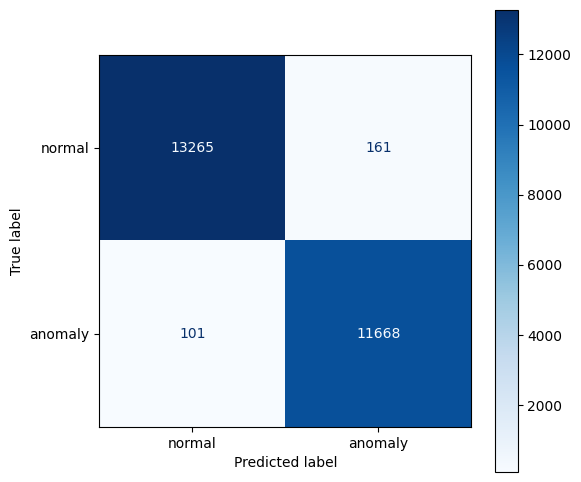

In [29]:
# Visualización gráfica intuitiva de la matriz de confusión
disp = ConfusionMatrixDisplay.from_predictions(y_val, y_pred, labels=["normal", "anomaly"], cmap="Blues")
disp.figure_.set_size_inches(6, 6)

In [30]:
# Cálculo de indicadores de rendimiento clave
print("Precisión (Precision):", precision_score(y_val, y_pred, pos_label='anomaly'))
print("Sensibilidad (Recall):", recall_score(y_val, y_pred, pos_label='anomaly'))
print("Puntaje F1 (F1 score):", f1_score(y_val, y_pred, pos_label='anomaly'))

Precisión (Precision): 0.9863893820272213
Sensibilidad (Recall): 0.9914181323816806
Puntaje F1 (F1 score): 0.9888973641834053


El modelo equilibra de manera efectiva la identificación de amenazas (alta sensibilidad) con una baja tasa de falsos positivos (alta precisión). Esto se refleja en un excelente desempeño consolidado (Puntaje F1 alto).

## 7. Gráficas ROC y Sensibilidad-Precisión

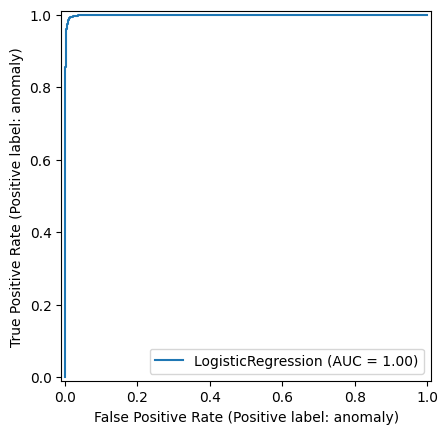

In [31]:
# Trazamos la Curva Característica Operativa del Receptor (ROC)
RocCurveDisplay.from_estimator(clf, X_val_prep, y_val, pos_label='anomaly')

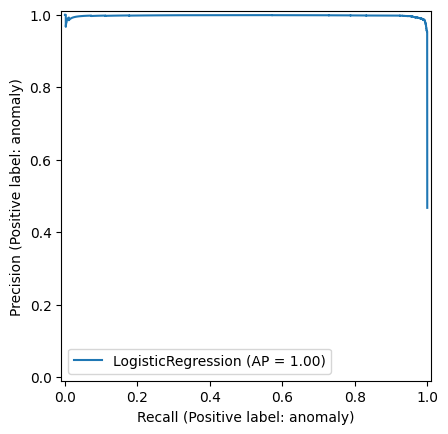

In [32]:
# Evaluamos visualmente el compromiso entre la Sensibilidad y la Precisión
PrecisionRecallDisplay.from_estimator(clf, X_val_prep, y_val, pos_label='anomaly')